
Feature Importance (Based on Neural Network Weights):
         Feature  Importance
    PlateLocSide    0.246739
  PlateLocHeight    0.219857
        RelSpeed    0.203235
       Extension    0.195330
InducedVertBreak    0.193462
        SpinRate    0.183766
       RelHeight    0.181568
       HorzBreak    0.175169
        SpinAxis    0.171658
         RelSide    0.155735
   VertApprAngle    0.150539
       VertBreak    0.136004
   HorzApprAngle    0.130837


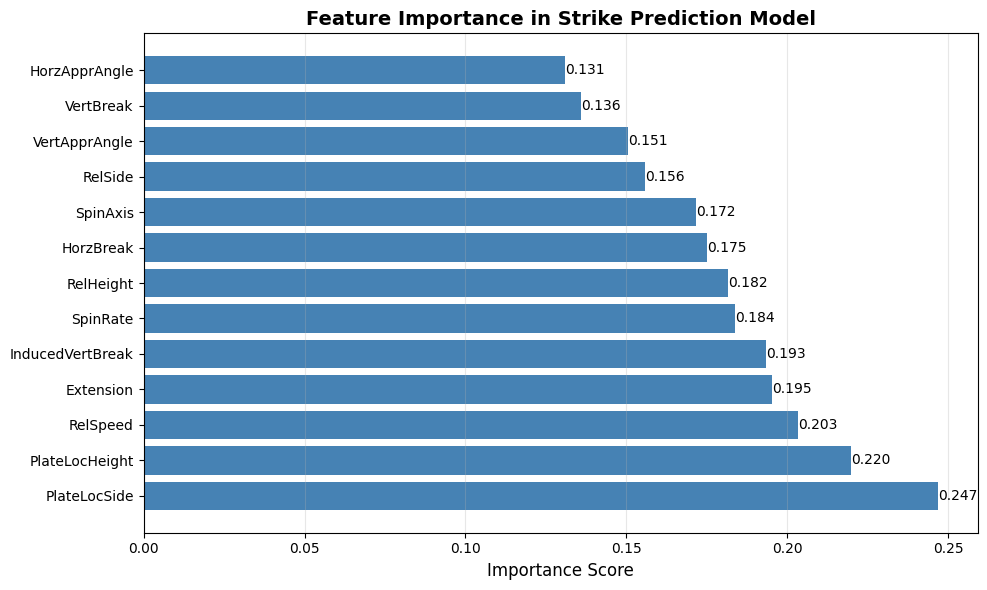


✓ Neural network model complete!


In [20]:
# Feature importance - analyze which features influence predictions the most

# Get the weights from the input layer (first layer of coefs_)
first_layer_weights = model.coefs_[0]  # Shape: (n_features, n_neurons_in_hidden_layer)

# Calculate mean absolute weights for each feature
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)

# Create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Based on Neural Network Weights):")
print(importance_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance in Strike Prediction Model', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Neural network model complete!")

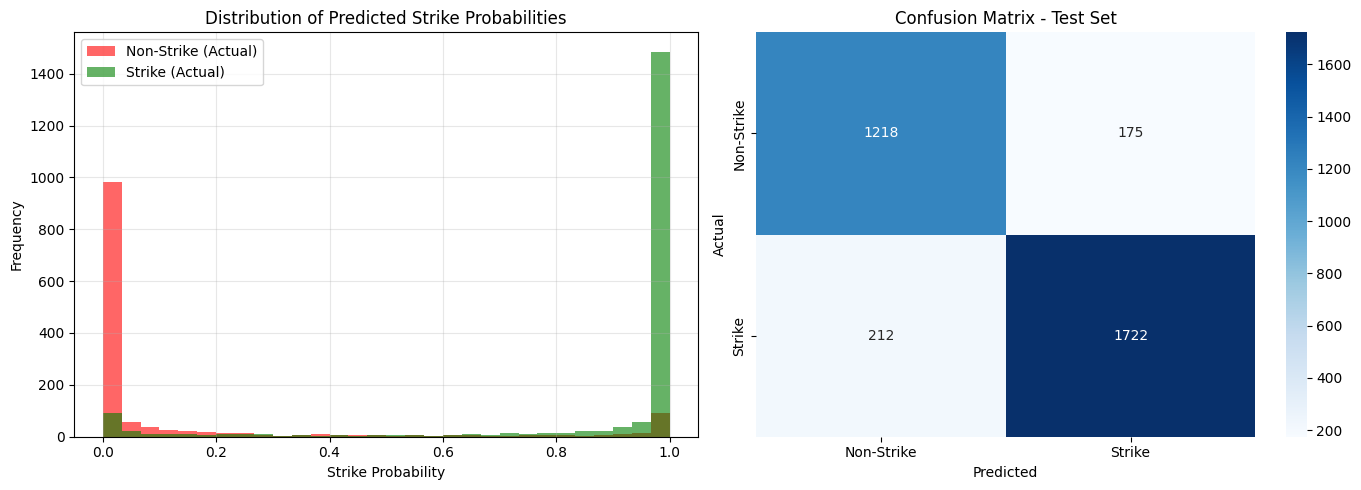

Visualizations displayed.


In [18]:
# Visualize strike probability distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probabilities
axes[0].hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Non-Strike (Actual)', color='red')
axes[0].hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Strike (Actual)', color='green')
axes[0].set_xlabel('Strike Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Strike Probabilities')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Non-Strike', 'Strike'],
            yticklabels=['Non-Strike', 'Strike'])
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
axes[1].set_title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

print("Visualizations displayed.")

In [17]:
# Display sample predictions with probabilities

n_samples = min(20, len(X_test))
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

results_df = pd.DataFrame({
    'Actual': y_test[sample_indices],
    'Predicted': y_test_pred[sample_indices],
    'Strike_Probability': y_test_pred_proba[sample_indices].flatten(),
    'Correct': (y_test_pred[sample_indices] == y_test[sample_indices]).astype(int)
})

# Map 0/1 to readable labels
results_df['Actual'] = results_df['Actual'].map({0: 'Non-Strike', 1: 'Strike'})
results_df['Predicted'] = results_df['Predicted'].map({0: 'Non-Strike', 1: 'Strike'})
results_df['Correct'] = results_df['Correct'].map({0: '❌', 1: '✓'})

print("Sample Predictions (20 random test samples):")
print(results_df.to_string())

# Calculate overall strike percentage predictions
print("\n" + "="*80)
print("STRIKE PERCENTAGE ANALYSIS")
print("="*80)
print(f"Actual strike percentage in test set: {y_test.mean() * 100:.2f}%")
print(f"Predicted strike percentage in test set: {y_test_pred.mean() * 100:.2f}%")
print(f"Mean strike probability from model: {y_test_pred_proba.mean() * 100:.2f}%")

Sample Predictions (20 random test samples):
        Actual   Predicted  Strike_Probability Correct
0       Strike      Strike            0.999535       ✓
1       Strike      Strike            1.000000       ✓
2       Strike      Strike            0.999996       ✓
3   Non-Strike      Strike            0.986575       ❌
4       Strike  Non-Strike            0.210332       ❌
5       Strike  Non-Strike            0.185864       ❌
6       Strike      Strike            0.999998       ✓
7       Strike      Strike            0.996806       ✓
8   Non-Strike      Strike            0.741371       ❌
9       Strike      Strike            1.000000       ✓
10      Strike      Strike            0.999976       ✓
11  Non-Strike  Non-Strike            0.000003       ✓
12      Strike      Strike            0.999962       ✓
13  Non-Strike      Strike            0.662461       ❌
14      Strike      Strike            0.999982       ✓
15      Strike      Strike            0.999995       ✓
16  Non-Strike  Non-

## Section 8: Make Predictions on New Data

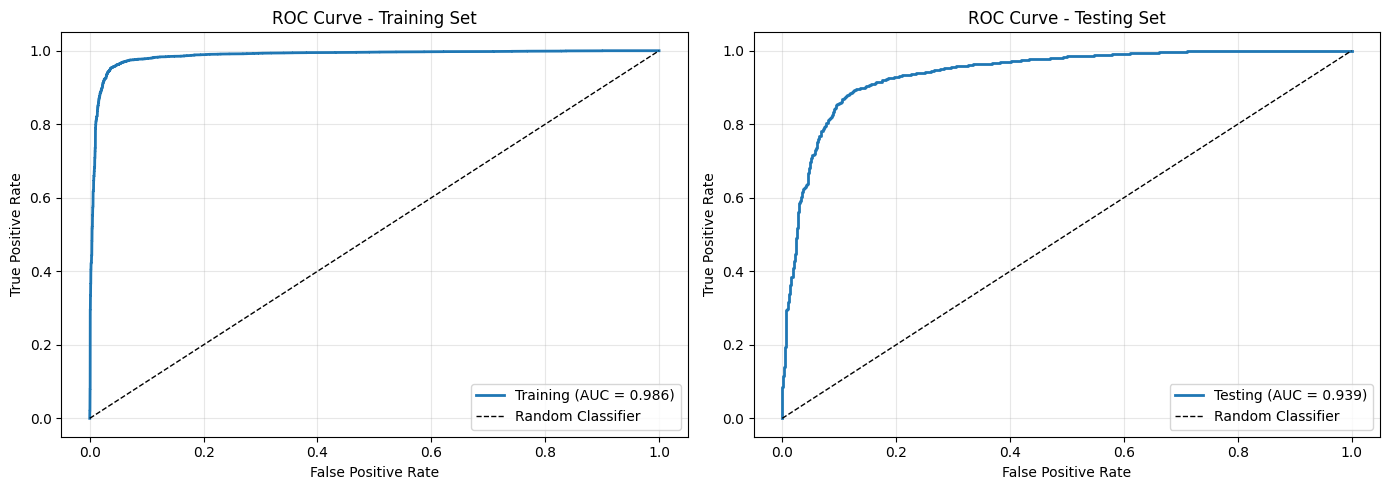

ROC curves displayed.


In [16]:
# Plot ROC curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)

axes[0].plot(fpr_train, tpr_train, label=f'Training (AUC = {roc_auc_train:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Training Set')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing set ROC curve
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

axes[1].plot(fpr_test, tpr_test, label=f'Testing (AUC = {roc_auc_test:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Testing Set')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC curves displayed.")

In [15]:
# Make predictions on training and testing sets

# Get probability predictions
y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Get binary predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
print("="*80)
print("TRAINING SET PERFORMANCE")
print("="*80)
print(f"Accuracy: {np.mean(y_train_pred == y_train) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Non-Strike', 'Strike']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\n" + "="*80)
print("TESTING SET PERFORMANCE")
print("="*80)
print(f"Accuracy: {np.mean(y_test_pred == y_test) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Non-Strike', 'Strike']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Calculate MSE, MAE, and R² score
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n" + "="*80)
print("ADDITIONAL METRICS (Testing Set)")
print("="*80)
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R² Score: {r2_test:.4f}")

TRAINING SET PERFORMANCE
Accuracy: 95.70%
ROC-AUC Score: 0.9863

Classification Report:
              precision    recall  f1-score   support

  Non-Strike       0.94      0.96      0.95      5569
      Strike       0.97      0.95      0.96      7736

    accuracy                           0.96     13305
   macro avg       0.95      0.96      0.96     13305
weighted avg       0.96      0.96      0.96     13305


Confusion Matrix:
[[5357  212]
 [ 360 7376]]

TESTING SET PERFORMANCE
Accuracy: 88.37%
ROC-AUC Score: 0.9390

Classification Report:
              precision    recall  f1-score   support

  Non-Strike       0.85      0.87      0.86      1393
      Strike       0.91      0.89      0.90      1934

    accuracy                           0.88      3327
   macro avg       0.88      0.88      0.88      3327
weighted avg       0.88      0.88      0.88      3327


Confusion Matrix:
[[1218  175]
 [ 212 1722]]

ADDITIONAL METRICS (Testing Set)
Mean Squared Error (MSE): 0.1163
Mean Absolu

## Section 7: Evaluate Model Performance

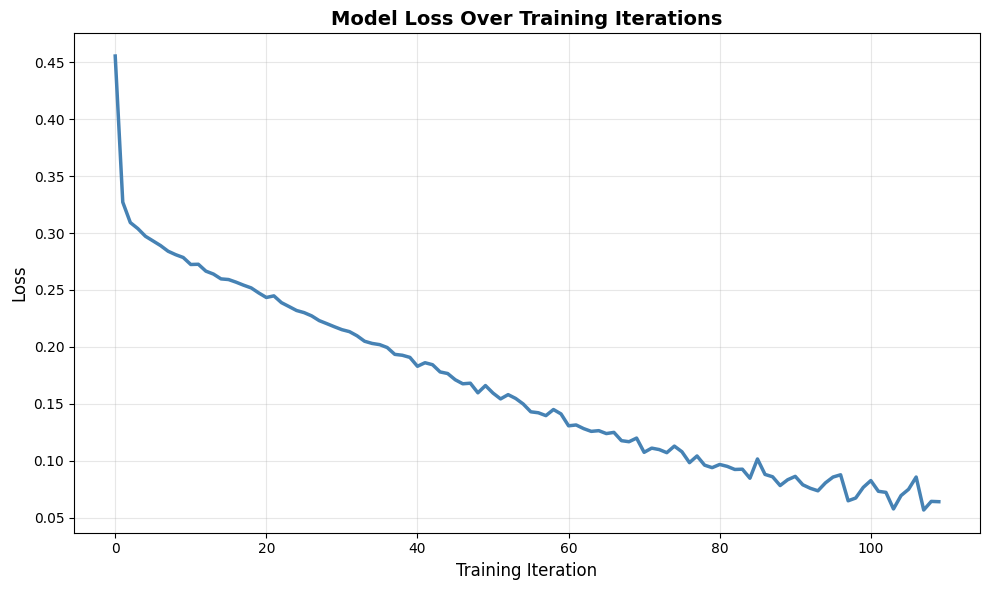

Training loss plot displayed.


In [13]:
# Plot training loss over iterations

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Loss plot
ax.plot(model.loss_curve_, linewidth=2.5, color='steelblue')
ax.set_xlabel('Training Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Model Loss Over Training Iterations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training loss plot displayed.")

In [12]:
# Train the model

print("Starting model training...")
model.fit(X_train_scaled, y_train)

print("\n✓ Model training completed!")
print(f"Training iterations: {model.n_iter_}")
print(f"Final training loss: {model.loss_:.6f}")

# Get training history
losses = model.loss_curve_
print(f"Loss curve length: {len(losses)}")
print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss: {losses[-1]:.6f}")

Starting model training...
Iteration 1, loss = 0.45537519
Validation score: 0.843668
Iteration 2, loss = 0.32709715
Validation score: 0.833145
Iteration 3, loss = 0.30917856
Validation score: 0.845923
Iteration 4, loss = 0.30385101
Validation score: 0.850808
Iteration 5, loss = 0.29713999
Validation score: 0.848177
Iteration 6, loss = 0.29306781
Validation score: 0.852311
Iteration 7, loss = 0.28896907
Validation score: 0.848553
Iteration 8, loss = 0.28400136
Validation score: 0.848929
Iteration 9, loss = 0.28098589
Validation score: 0.840661
Iteration 10, loss = 0.27851604
Validation score: 0.851935
Iteration 11, loss = 0.27236741
Validation score: 0.856069
Iteration 12, loss = 0.27256675
Validation score: 0.848177
Iteration 13, loss = 0.26652358
Validation score: 0.856069
Iteration 14, loss = 0.26396930
Validation score: 0.848553
Iteration 15, loss = 0.25972577
Validation score: 0.848177
Iteration 16, loss = 0.25915581
Validation score: 0.853814
Iteration 17, loss = 0.25682679
Valida

## Section 6: Train the Model

In [11]:
# Create a Multi-Layer Perceptron neural network classifier

model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),  # 4 hidden layers with decreasing neurons
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    batch_size=32,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    random_state=42,
    verbose=1
)

print("Neural Network Model Created:")
print(f"Hidden layers: (128, 64, 32, 16)")
print(f"Activation function: ReLU")
print(f"Solver: Adam")
print(f"Max iterations: 500")
print(f"Early stopping enabled with patience of 20")

Neural Network Model Created:
Hidden layers: (128, 64, 32, 16)
Activation function: ReLU
Solver: Adam
Max iterations: 500
Early stopping enabled with patience of 20


## Section 5: Build the Neural Network Model

In [10]:
# Separate features and target
X = df_model[available_features].values
y = df_model['Strike'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Strike percentage in full dataset: {y.mean() * 100:.2f}%")

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Strike percentage in training set: {y_train.mean() * 100:.2f}%")
print(f"Strike percentage in testing set: {y_test.mean() * 100:.2f}%")

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Data split and scaling completed!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features shape: (16632, 13)
Target shape: (16632,)
Strike percentage in full dataset: 58.14%

Training set size: 13305 samples
Testing set size: 3327 samples
Strike percentage in training set: 58.14%
Strike percentage in testing set: 58.13%

✓ Data split and scaling completed!
X_train_scaled shape: (13305, 13)
X_test_scaled shape: (3327, 13)


## Section 4: Split Data into Training and Testing Sets

In [9]:
# Create target variable: 1 for strike, 0 for non-strike

def is_strike(pitch_call):
    """Convert PitchCall to binary strike (1) or non-strike (0)"""
    if pd.isna(pitch_call):
        return np.nan
    pitch_call_str = str(pitch_call).lower()
    # Strike calls include: StrikeSwinging, StrikeCalled, InPlay, FoulBall
    strike_keywords = ['strike', 'inplay', 'foul']
    return 1 if any(keyword in pitch_call_str for keyword in strike_keywords) else 0

df_combined['Strike'] = df_combined['PitchCall'].apply(is_strike)

print("Strike distribution:")
print(df_combined['Strike'].value_counts())
print(f"\nStrike percentage: {df_combined['Strike'].mean() * 100:.2f}%")

# Select relevant features for the model
# These are pitch kinematic and trajectory features
feature_columns = [
    'RelSpeed', 'RelHeight', 'RelSide', 'VertBreak', 'HorzBreak', 
    'PlateLocHeight', 'PlateLocSide', 'SpinRate', 'SpinAxis',
    'Tilt', 'Extension', 'InducedVertBreak', 'VertApprAngle', 'HorzApprAngle'
]

# Check which columns exist
available_features = [col for col in feature_columns if col in df_combined.columns]
print(f"\nUsing {len(available_features)} features: {available_features}")

# Create working dataset
df_model = df_combined[available_features + ['Strike']].copy()

# Remove rows with missing target values
df_model = df_model[df_model['Strike'].notna()].copy()

print(f"Dataset shape after removing NaN targets: {df_model.shape}")

# Convert all columns to numeric, replacing non-numeric values with NaN
for col in available_features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

print(f"\nMissing values before imputation:")
missing_counts = df_model.isnull().sum()
print(missing_counts)

# Remove columns that have too many missing values (>50% missing)
cols_to_drop = [col for col in available_features if missing_counts[col] / len(df_model) > 0.5]
print(f"\nDropping columns with >50% missing values: {cols_to_drop}")

available_features = [col for col in available_features if col not in cols_to_drop]
df_model = df_model[available_features + ['Strike']].copy()

print(f"Remaining features: {available_features}")

# Fill missing values with median for each column
for col in available_features:
    if df_model[col].isnull().sum() > 0:
        median_val = df_model[col].median()
        df_model[col].fillna(median_val, inplace=True)

print(f"\nMissing values after imputation:")
print(df_model.isnull().sum())

# Remove any remaining rows with NaN
df_model = df_model.dropna()

# Check for infinite values and replace them with median
for col in available_features:
    inf_mask = np.isinf(df_model[col])
    if inf_mask.any():
        median_val = df_model.loc[~inf_mask, col].median()
        df_model.loc[inf_mask, col] = median_val

print(f"\nFinal dataset shape: {df_model.shape}")
print(f"✓ Data preprocessing completed!")

Strike distribution:
Strike
1    9726
0    7050
Name: count, dtype: int64

Strike percentage: 57.98%

Using 14 features: ['RelSpeed', 'RelHeight', 'RelSide', 'VertBreak', 'HorzBreak', 'PlateLocHeight', 'PlateLocSide', 'SpinRate', 'SpinAxis', 'Tilt', 'Extension', 'InducedVertBreak', 'VertApprAngle', 'HorzApprAngle']
Dataset shape after removing NaN targets: (16776, 15)

Missing values before imputation:
RelSpeed              137
RelHeight             137
RelSide               137
VertBreak             137
HorzBreak             137
PlateLocHeight        137
PlateLocSide          137
SpinRate              144
SpinAxis              137
Tilt                16776
Extension             137
InducedVertBreak      137
VertApprAngle         137
HorzApprAngle         137
Strike                  0
dtype: int64

Dropping columns with >50% missing values: ['Tilt']
Remaining features: ['RelSpeed', 'RelHeight', 'RelSide', 'VertBreak', 'HorzBreak', 'PlateLocHeight', 'PlateLocSide', 'SpinRate', 'SpinAxis

## Section 3: Data Preprocessing and Feature Engineering

In [7]:
# Load data from multiple folders in the datasets directory

datasets_path = r'c:\Users\sreey\OneDrive\Desktop\BaseBall\Analytics\datasets'

# List to store all dataframes
dfs = []

# Load from main datasets folder
main_files = glob.glob(os.path.join(datasets_path, '*.csv'))
print(f"Found {len(main_files)} CSV files in main datasets folder")

for file in main_files:
    if not file.endswith('.url'):  # Skip .url files
        try:
            df = pd.read_csv(file)
            dfs.append(df)
            print(f"Loaded: {os.path.basename(file)} - Shape: {df.shape}")
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Load from TrackMan.csv subfolder
trackman_files = glob.glob(os.path.join(datasets_path, 'TrackMan.csv', '*.csv'))
print(f"\nFound {len(trackman_files)} CSV files in TrackMan.csv subfolder")

for file in trackman_files:
    if not file.endswith('.url'):
        try:
            df = pd.read_csv(file)
            dfs.append(df)
            print(f"Loaded: {os.path.basename(file)} - Shape: {df.shape}")
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Concatenate all dataframes
df_combined = pd.concat(dfs, ignore_index=True)
print(f"\n✓ Combined dataset shape: {df_combined.shape}")
print(f"Total rows: {len(df_combined)}")
print(f"Total columns: {len(df_combined.columns)}")

Found 27 CSV files in main datasets folder
Loaded: 20250426-SpuhlerFieldMain-1_unverified.csv - Shape: (295, 167)
Loaded: 20250502-SpuhlerFieldMain-1_unverified.csv - Shape: (228, 167)
Loaded: 20250503-SpuhlerFieldMain-1_unverified.csv - Shape: (267, 167)
Loaded: 20250504-SpuhlerFieldMain-1_unverified.csv - Shape: (259, 167)
Loaded: 20250515-SpuhlerFieldMain-1_unverified.csv - Shape: (264, 167)
Loaded: 20250516-SpuhlerFieldMain-1_unverified.csv - Shape: (320, 167)
Loaded: 20250517-SpuhlerFieldMain-1_unverified.csv - Shape: (280, 167)
Loaded: 20250919-SpuhlerFieldMain-Private-4_unverified.csv - Shape: (142, 167)
Loaded: 20250920-SpuhlerFieldMain-Private-1_unverified.csv - Shape: (90, 167)
Loaded: 20250926-SpuhlerFieldMain-Private-1_unverified.csv - Shape: (226, 167)
Loaded: 20250927-SpuhlerFieldMain-Private-2_unverified.csv - Shape: (141, 167)
Loaded: 20251001-SpuhlerFieldMain-Private-1_unverified.csv - Shape: (21, 167)
Loaded: 20251004-SpuhlerFieldMain-Private-1_unverified.csv - Shape:

## Section 2: Load and Explore the Dataset

In [2]:
# Section 1: Import Required Libraries

import pandas as pd
import numpy as np
import os
import glob
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


# Neural Network for Baseball Strike Prediction

This notebook builds a basic neural network to predict the overall strike percentage from TrackMan baseball pitch data across multiple datasets.